In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: better plot style
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv("../data/processed/race_driver_labels.csv")

df.columns

Index(['raceId', 'driverId', 'constructorId', 'grid', 'positionOrder',
       'points', 'statusId', 'year', 'round', 'circuitId', 'raceName',
       'qualifyingPosition', 'avgLapTime_ms', 'minLapTime_ms', 'lapsCompleted',
       'pitStopCount', 'avgPitDuration_ms', 'driverName_x',
       'constructorName_x', 'driverName_y', 'constructorName_y', 'driverName',
       'constructorName', 'finishPosition', 'avgLapTime_s',
       'constructorPoints'],
      dtype='object')

In [32]:
df["positionOrder"].isna().sum()
finish_positions = df["finishPosition"].dropna()
finish_positions = finish_positions.astype(int)

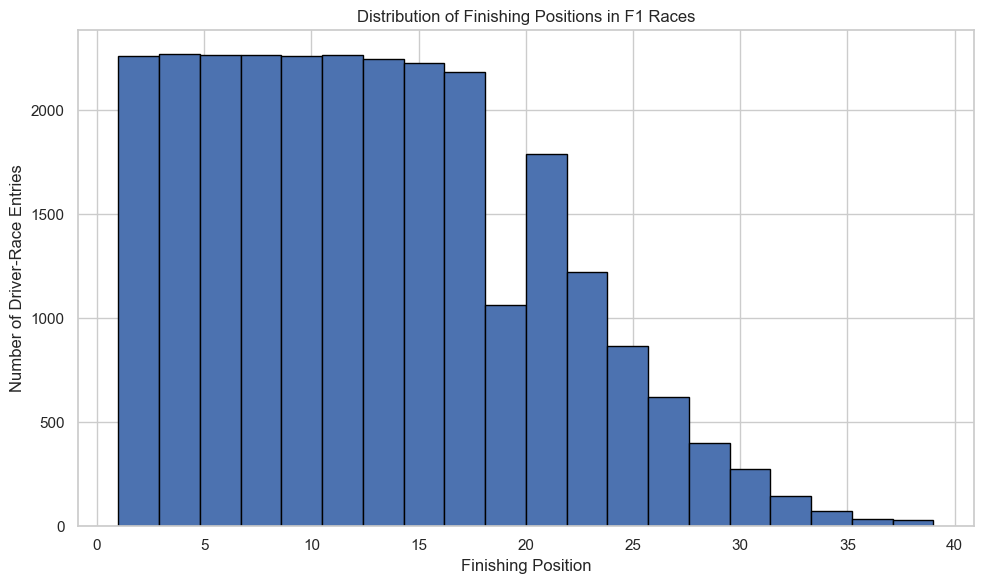

In [33]:
plt.figure(figsize=(10, 6))

plt.hist(
    finish_positions,
    bins=20,
    edgecolor="black"
)

plt.xlabel("Finishing Position")
plt.ylabel("Number of Driver-Race Entries")
plt.title("Distribution of Finishing Positions in F1 Races")

plt.tight_layout()
plt.savefig("../report/figures/finish_position_histogram.png")
plt.show()

Interpretation:
The distribution of finishing positions is highly skewed toward lower-ranked positions, with many more observations in mid-to-backfield finishes than podium positions. This reflects the limited number of top finishing slots per race and suggests that predicting exact finishing position is a challenging regression task. This insight motivates exploring rank-based or grouped prediction strategies in later modeling stages.

In [35]:
print(df[["qualifyingPosition", "finishPosition"]].isna().sum())

qualifyingPosition    16265
finishPosition            0
dtype: int64


In [36]:
scatter_df = df[
    (df["qualifyingPosition"].notna()) &
    (df["finishPosition"].notna()) &
    (df["qualifyingPosition"] > 0) &
    (df["finishPosition"] > 0)
].copy()

scatter_df["qualifyingPosition"] = scatter_df["qualifyingPosition"].astype(int)
scatter_df["finishPosition"] = scatter_df["finishPosition"].astype(int)


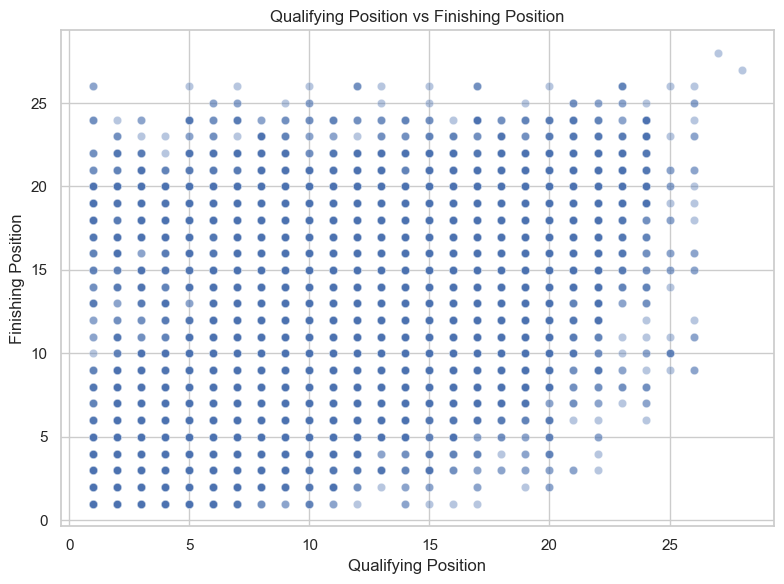

In [37]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=scatter_df,
    x="qualifyingPosition",
    y="finishPosition",
    alpha=0.4
)

plt.title("Qualifying Position vs Finishing Position")
plt.xlabel("Qualifying Position")
plt.ylabel("Finishing Position")

plt.tight_layout()
plt.savefig("../report/figures/qualifying_vs_finish.png", dpi=300)
plt.show()


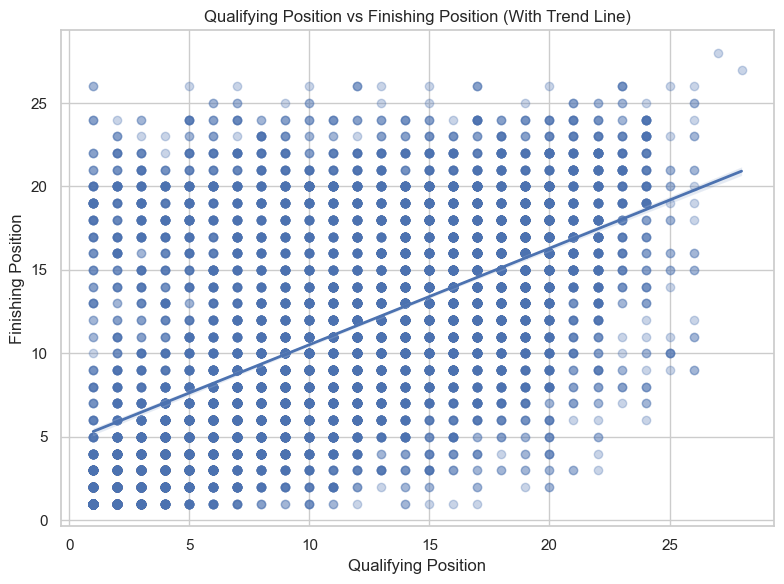

In [38]:
plt.figure(figsize=(8, 6))

sns.regplot(
    data=scatter_df,
    x="qualifyingPosition",
    y="finishPosition",
    scatter_kws={"alpha": 0.3},
    line_kws={"linewidth": 2}
)

plt.title("Qualifying Position vs Finishing Position (With Trend Line)")
plt.xlabel("Qualifying Position")
plt.ylabel("Finishing Position")

plt.tight_layout()
plt.show()


The scatter plot shows a clear positive relationship between qualifying position and finishing position, indicating that drivers starting closer to the front tend to finish higher. However, the wide spread of points demonstrates significant race variability due to factors such as pit strategy, reliability, and race incidents. This justifies the use of machine learning models rather than deterministic rules.

Important Note:
Due to the discrete nature of Formula One positions and the large historical dataset spanning multiple decades, standard scatter plots exhibit overplotting. To improve interpretability, jittered and density-based visualisations should be used while preserving the underlying data distribution.

In [39]:
corr = scatter_df["qualifyingPosition"].corr(scatter_df["finishPosition"])
print(f"Pearson correlation: {corr:.3f}")

Pearson correlation: 0.576


In [40]:
df = pd.read_csv("../data/processed/race_driver_labels.csv")

df.columns

Index(['raceId', 'driverId', 'constructorId', 'grid', 'positionOrder',
       'points', 'statusId', 'year', 'round', 'circuitId', 'raceName',
       'qualifyingPosition', 'avgLapTime_ms', 'minLapTime_ms', 'lapsCompleted',
       'pitStopCount', 'avgPitDuration_ms', 'driverName_x',
       'constructorName_x', 'driverName_y', 'constructorName_y', 'driverName',
       'constructorName', 'finishPosition', 'avgLapTime_s',
       'constructorPoints'],
      dtype='object')

In [41]:
df[["constructorName", "finishPosition"]].isna().sum()

constructorName    0
finishPosition     0
dtype: int64

In [42]:
constructor_perf = (
    df.dropna(subset=["constructorName", "finishPosition"])
      .groupby("constructorName")
      .agg(
          avgFinish=("finishPosition", "mean"),
          raceEntries=("finishPosition", "count")
      )
      .reset_index()
)

In [43]:
constructor_perf = constructor_perf[constructor_perf["raceEntries"] >= 100]

In [44]:
constructor_perf = constructor_perf.sort_values("avgFinish")

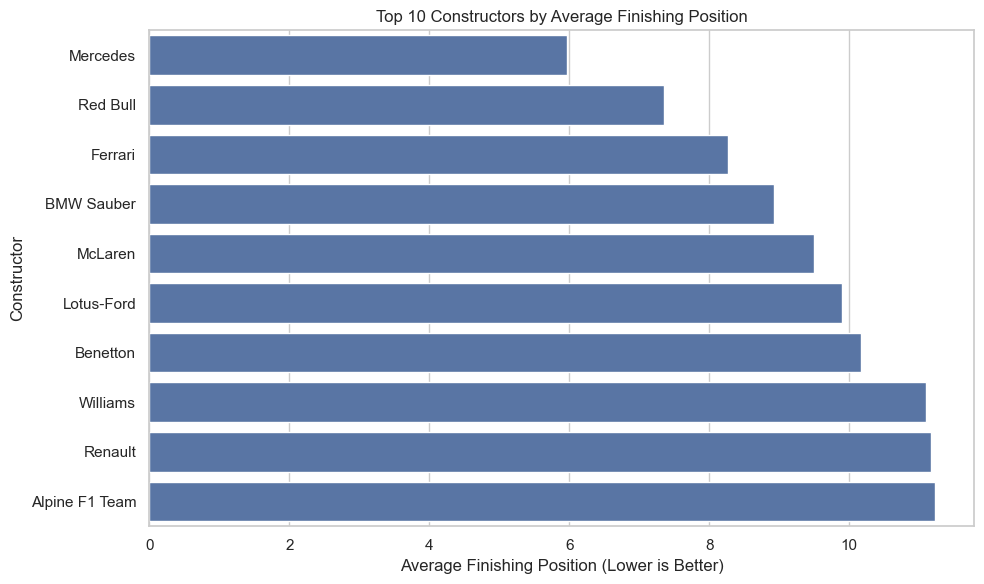

In [46]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=constructor_perf.head(10),
    x="avgFinish",
    y="constructorName"
)

plt.title("Top 10 Constructors by Average Finishing Position")
plt.xlabel("Average Finishing Position (Lower is Better)")
plt.ylabel("Constructor")

plt.tight_layout()
plt.savefig("../report/figures/top_constructors_avg_finish.png", dpi=300)
plt.show()

Interpretation:
The analysis shows strong performance differences between constructors, with top teams consistently achieving lower average finishing positions and higher points per race. This confirms that constructor identity is a critical explanatory feature and should be included in predictive models. The magnitude of performance gaps justifies modeling constructor effects explicitly rather than treating all drivers equally.

In [47]:
constructor_points = (
    df.dropna(subset=["constructorName", "constructorPoints"])
      .groupby("constructorName")
      .agg(
          avgPoints=("constructorPoints", "mean")
      )
      .reset_index()
      .sort_values("avgPoints", ascending=False)
)

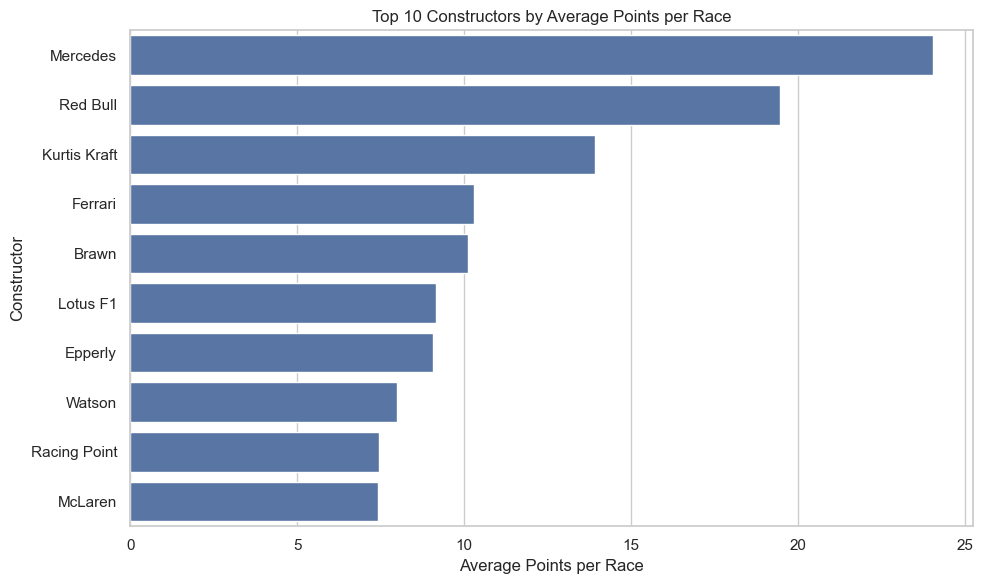

In [48]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=constructor_points.head(10),
    x="avgPoints",
    y="constructorName"
)

plt.title("Top 10 Constructors by Average Points per Race")
plt.xlabel("Average Points per Race")
plt.ylabel("Constructor")

plt.tight_layout()
plt.show()

In [3]:
df["avgLapTime_s"].describe()

count    11041.000000
mean        98.540312
std         22.402558
min         62.932345
25%         85.307776
50%         95.233385
75%        106.403143
max        753.493000
Name: avgLapTime_s, dtype: float64

In [4]:
lap_df = df[
    (df["avgLapTime_s"].notna()) &
    (df["avgLapTime_s"] > 40) &    # too fast = invalid
    (df["avgLapTime_s"] < 200)     # too slow = outlier
].copy()

F1 lap times are rarely below 60s
Over 200s usually indicates safety car / in-lap / pit anomalies

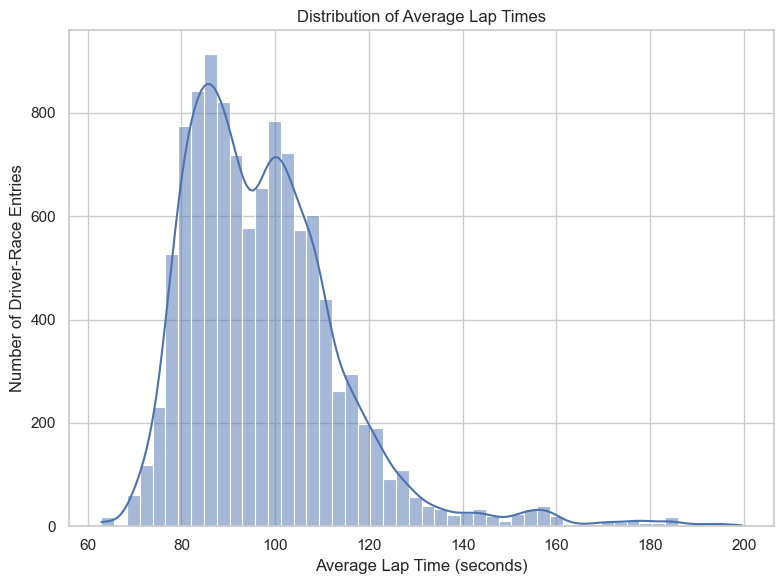

In [6]:
plt.figure(figsize=(8, 6))

sns.histplot(
    lap_df["avgLapTime_s"],
    bins=50,
    kde=True
)

plt.title("Distribution of Average Lap Times")
plt.xlabel("Average Lap Time (seconds)")
plt.ylabel("Number of Driver-Race Entries")

plt.tight_layout()
plt.savefig("../report/figures/lap_time_distribution.png", dpi=300)
plt.show()

Interpretation:
The distribution of average lap times shows a right-skewed pattern, reflecting variability across circuits and race conditions. Most lap times cluster within a narrow range, indicating high consistency among drivers, while outliers correspond to anomalous race conditions such as safety cars or technical issues. Constructor-level boxplots further demonstrate systematic performance differences, supporting the inclusion of lap time features and constructor effects in predictive models.

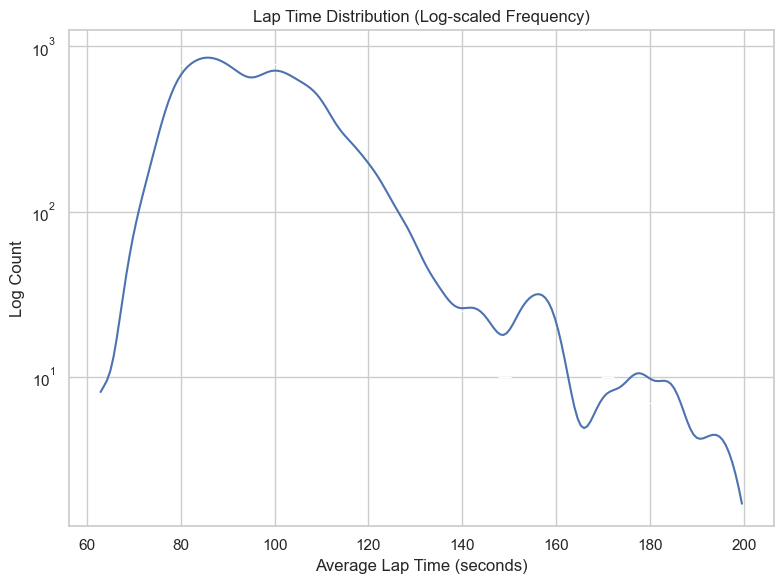

In [7]:
plt.figure(figsize=(8, 6))

sns.histplot(
    lap_df["avgLapTime_s"],
    bins=50,
    kde=True,
    log_scale=(False, True)
)

plt.title("Lap Time Distribution (Log-scaled Frequency)")
plt.xlabel("Average Lap Time (seconds)")
plt.ylabel("Log Count")

plt.tight_layout()
plt.show()

Log-scale view ^

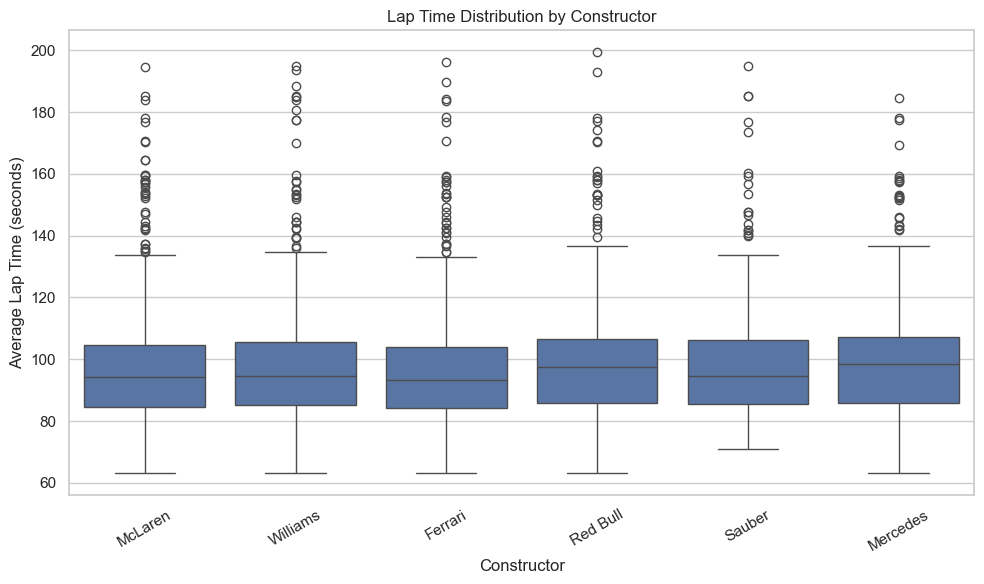

In [8]:
top_constructors = (
    lap_df.groupby("constructorName")
          .size()
          .sort_values(ascending=False)
          .head(6)
          .index
)

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=lap_df[lap_df["constructorName"].isin(top_constructors)],
    x="constructorName",
    y="avgLapTime_s"
)

plt.xticks(rotation=30)
plt.title("Lap Time Distribution by Constructor")
plt.xlabel("Constructor")
plt.ylabel("Average Lap Time (seconds)")

plt.tight_layout()
plt.show()

Lap time by constructor ^

In [9]:
df.dtypes
numeric_df = df.select_dtypes(include=["int64", "float64"])

Correlation Heatmap: 

Correlation only makes sense for numeric data.
Explicitly select numeric columns:
-Avoids errors
-Avoids meaningless correlations
-Cleaner heatmap

In [10]:
features = [
    "qualifyingPosition",
    "finishPosition",
    "avgLapTime_s",
    "constructorPoints",
    "grid",
    "lapsCompleted"
]

heatmap_df = numeric_df[features].dropna()


In [11]:
corr_matrix = heatmap_df.corr()
corr_matrix

,qualifyingPosition,finishPosition,avgLapTime_s,constructorPoints,grid,lapsCompleted
qualifyingPosition,1.000000,0.614334,0.077348,-0.614077,0.943422,-0.121096
finishPosition,0.614334,1.000000,0.118638,-0.653250,0.583898,-0.508848
avgLapTime_s,0.077348,0.118638,1.000000,-0.025123,0.072141,-0.393516
constructorPoints,-0.614077,-0.653250,-0.025123,1.000000,-0.588581,0.179922
grid,0.943422,0.583898,0.072141,-0.588581,1.000000,-0.117974
lapsCompleted,-0.121096,-0.508848,-0.393516,0.179922,-0.117974,1.000000


Correlation Matrix ^

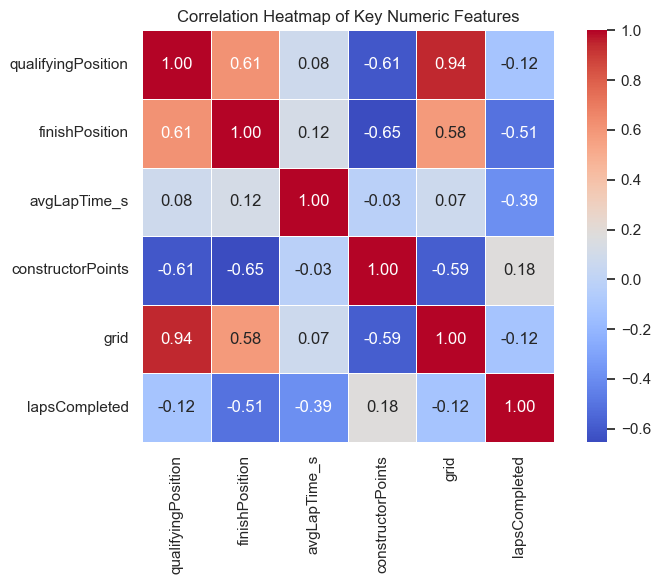

In [13]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
    linewidths=0.5
)

plt.title("Correlation Heatmap of Key Numeric Features")

plt.tight_layout()
plt.savefig("../report/figures/correlation_heatmap.png", dpi=300)
plt.show()

Interpretation:
The correlation heatmap shows that qualifying position has a strong positive correlation with finishing position, confirming its predictive relevance. Average lap time is also moderately correlated with finishing position, indicating that race pace contributes significantly to outcomes. Constructor points exhibit strong relationships with both finishing position and lap time, highlighting constructor performance as a key explanatory factor. No extreme multicollinearity is observed, supporting the use of these features in regression and tree-based models.

In [14]:
corr_with_finish = corr_matrix["finishPosition"].sort_values()
corr_with_finish

constructorPoints    -0.653250
lapsCompleted        -0.508848
avgLapTime_s          0.118638
grid                  0.583898
qualifyingPosition    0.614334
finishPosition        1.000000
Name: finishPosition, dtype: float64